## Imports

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.mlab   as mlab

from xkte_nonadaptive_new import kernel_dr_two_sample_test_agnostic
from dr_kte_adaptive import xMMD2_vsdr_fold_generic
from kte_new import kernel_two_sample_test_nonuniform
from baselines import cadr_test, hadad_test, fit_krr_predict
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import cdist
from scipy.special import expit
from scipy.stats import bernoulli
from numpy.polynomial.polynomial import polyval
from sklearn.linear_model import LogisticRegression

from scipy.stats import norm
import scipy.stats as stats
import statistics

from tqdm import tqdm

import seaborn as sns
import pandas as pd
import time
import os


In [2]:
import numpy as np

def scenario_signal_vector(ns, scenario, rng, beta_mix=2.0, beta_uniform=4.0):
    """
    Scenario-driven *scalar* multipliers for the heterogeneous TE direction u.

    Output: vector g ∈ R^ns such that Δ_t = g_t * (X_t @ u)
    """
    if scenario == 'I':   # no treatment effect (H0)
        return np.zeros(ns)

    if scenario == 'II':  # constant magnitude (positive)
        return np.full(ns, 2.0)

    if scenario == 'III':  # random sign * fixed magnitude
        signs = rng.binomial(1, 0.5, ns) * 2 - 1
        return signs.astype(float) * beta_mix

    if scenario == 'IV':  # continuous heterogeneous magnitude
        return rng.uniform(-beta_uniform, beta_uniform, ns)

    return np.zeros(ns)


def make_data_with_scenarios(n, d, rng, sigma_eps=1.0, scenario='I'):
    """
    Linear baseline + scenario-based heterogeneous TE along direction u.
    Δ_t = g_t * (X_t @ u)
    """

    # Gaussian covariates
    X = rng.normal(size=(n, d))

    # unit directions
    v = rng.normal(size=d)
    v /= np.linalg.norm(v) + 1e-12

    u = rng.normal(size=d)
    u /= np.linalg.norm(u) + 1e-12

    # baseline f(x)
    f = X @ v

    # scenario-based TE multipliers
    g = scenario_signal_vector(n, scenario, rng)

    # heterogeneous TE
    Delta = g * (X @ u)

    m0 = f
    m1 = f + Delta

    eps = rng.normal(scale=sigma_eps, size=n)

    return X, m0, m1, Delta, eps, u



def policy_explore_commit(x, t, t0, eps, u, winner):
    """
    Epsilon explore-then-commit with linear separator on x @ u.

    parameters
    ----------
    x : (d,) array
    t : int
    t0 : int
    eps : float
    u : (d,) array
    winner : int in {0,1}

    returns
    -------
    p1 : float
        Probability of action 1 at time t given context x.
    """
    if t < t0:
        return 0.5
    inS = (x @ u) > 0
    prefer1 = (winner == 1 and inS) or (winner == 0 and not inS)
    return (1.0 - eps) if prefer1 else eps


def generate_adaptive_data(
    ns,
    d=5,
    sigma_eps=1.0,
    scenario='I',
    t0=15,
    eps=0.001,
    rng=None,
    split="alternating",
):
    rng = rng or np.random.RandomState(0)

    # NEW: scenario-based DGP
    X, m0, m1, Delta, eps_noise, u = make_data_with_scenarios(
        n=ns,
        d=d,
        rng=rng,
        sigma_eps=sigma_eps,
        scenario=scenario,
    )

    # ETC winner
    winner = 1 if rng.rand() < 0.5 else 0

    # predictable propensities
    w = np.array(
        [policy_explore_commit(X[t], t, t0, eps, u, winner) for t in range(ns)]
    )

    # realized actions + outcomes
    A = (rng.rand(ns) < w).astype(int)
    Y = np.where(A == 1, m1, m0) + eps_noise


    # ------------------ folds for cross-evaluation ------------------ #
    if split == "alternating":
        idx0 = np.arange(0, ns, 2)
        idx1 = np.arange(1, ns, 2)
    else:  # chronological
        cut = ns // 2
        idx0 = np.arange(0, cut)
        idx1 = np.arange(cut, ns)

    X0 = X[idx0]
    X1 = X[idx1]

    N0, N1 = len(idx0), len(idx1)

    # For each t in fold0, compute policy probs on all X0
    Pi_fold0_on_0 = np.empty((N0, N0), dtype=float)
    for r, t in enumerate(idx0):
        Pi_fold0_on_0[r] = np.array(
            [policy_explore_commit(x, t, t0, eps, u, winner) for x in X0]
        )

    # For each t in fold1, compute policy probs on all X1
    Pi_fold1_on_1 = np.empty((N1, N1), dtype=float)
    for r, t in enumerate(idx1):
        Pi_fold1_on_1[r] = np.array(
            [policy_explore_commit(x, t, t0, eps, u, winner) for x in X1]
        )

    # Full matrix: for each t, policy probs on all X
    P_all = np.empty((ns, ns), dtype=np.float32)
    for t in range(ns):
        P_all[t] = np.array(
            [policy_explore_commit(x, t, t0, eps, u, winner) for x in X]
        )

    return X, A, Y[:, None], w, Pi_fold0_on_0, Pi_fold1_on_1, idx0, idx1, P_all


In [3]:
import numpy as np

def treatment_effect_vector(ns, scenario, rng, beta_mix=2.0, beta_uniform=4.0):
    if scenario == 'I':
        return np.zeros(ns)
    if scenario == 'II':
        return np.full(ns, 2.0)
    if scenario == 'III':
        signs = rng.binomial(1, 0.5, ns) * 2 - 1
        return signs.astype(float) * beta_mix
    if scenario == 'IV':
        return rng.uniform(-beta_uniform, beta_uniform, ns)
    return np.zeros(ns)

h_sigmoidal = lambda x: np.log(np.abs(16 * x - 8) + 1) * np.sign(x - 0.5)

def generate_adaptive_data(
    ns, d, beta_vec, noise_var, scenario,
    eps0=0.2, eps_min=0.01, power=0.99, lam=1e-2,
    rng=None, split="alternating"
):
    rng = rng or np.random.RandomState(0)

    X = rng.randn(ns, d)
    base = h_sigmoidal(X @ beta_vec)
    delta = treatment_effect_vector(ns, scenario, rng)

    Y0 = base + noise_var * rng.randn(ns)
    Y1 = base + noise_var * rng.randn(ns) + delta

    X_aug = np.hstack([np.ones((ns, 1)), X])

    S0 = np.diag([0.0] + [lam] * d)
    S1 = np.diag([0.0] + [lam] * d)
    b0 = np.zeros(d + 1)
    b1 = np.zeros(d + 1)

    def solve(S, b):
        try:
            return np.linalg.solve(S, b)
        except:
            return np.linalg.lstsq(S, b, rcond=None)[0]

    def eps_at(t):
        return max(eps_min, eps0 / ((t + 1)**power))

    A = np.zeros(ns, dtype=int)
    w = np.zeros(ns)
    Y = np.zeros(ns)

    theta0_snap = np.zeros((ns, d+1))
    theta1_snap = np.zeros((ns, d+1))

    for t in range(ns):
        th0 = solve(S0, b0)
        th1 = solve(S1, b1)
        theta0_snap[t] = th0
        theta1_snap[t] = th1

        eps_t = eps_at(t)
        z = X_aug[t]

        q0 = z @ th0
        q1 = z @ th1

        if q1 > q0:
            pi1 = 1 - 0.5 * eps_t
        elif q1 < q0:
            pi1 = 0.5 * eps_t
        else:
            pi1 = 0.5

        a = 1 if rng.rand() < pi1 else 0
        A[t] = a
        w[t] = pi1
        Y[t] = Y1[t] if a == 1 else Y0[t]

        if a == 0:
            S0 += np.outer(z, z)
            b0 += z * Y[t]
        else:
            S1 += np.outer(z, z)
            b1 += z * Y[t]

    if split == "alternating":
        idx0 = np.arange(0, ns, 2)
        idx1 = np.arange(1, ns, 2)
    else:
        cut = ns // 2
        idx0 = np.arange(0, cut)
        idx1 = np.arange(cut, ns)

    Z0 = X_aug[idx0]
    Z1 = X_aug[idx1]

    N0, N1 = len(idx0), len(idx1)

    Pi_fold0_on_0 = np.empty((N0, N0))
    for r, t in enumerate(idx0):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0 = Z0 @ th0; q1 = Z0 @ th1
        Pi_fold0_on_0[r] = np.where(
            q1 > q0, 1 - 0.5 * eps_t,
            np.where(q1 < q0, 0.5 * eps_t, 0.5)
        )

    Pi_fold1_on_1 = np.empty((N1, N1))
    for r, t in enumerate(idx1):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0 = Z1 @ th0; q1 = Z1 @ th1
        Pi_fold1_on_1[r] = np.where(
            q1 > q0, 1 - 0.5 * eps_t,
            np.where(q1 < q0, 0.5 * eps_t, 0.5)
        )

    P_all = np.empty((ns, ns), dtype=np.float32)
    for t in range(ns):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0_all = X_aug @ th0
        q1_all = X_aug @ th1
        P_all[t] = np.where(
            q1_all > q0_all, 1 - 0.5 * eps_t,
            np.where(q1_all < q0_all, 0.5 * eps_t, 0.5)
        )

    return X, A, Y[:, None], w, Pi_fold0_on_0, Pi_fold1_on_1, idx0, idx1, P_all


## Main function, which runs a list of tests based on its arguments

In [4]:
import os, time
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

def run_tests_adaptive(
    b_list, method_list, ns_list,
    name_folder, num_experiments, iterations,
    seed=0,
    split="alternating"   # 'alternating' or 'chronological'
):
    if split not in ("alternating", "chronological"):
        raise ValueError("split must be 'alternating' or 'chronological'.")

    noise_var = 0.5
    d = 5
    beta_vec = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    os.makedirs(name_folder, exist_ok=True)

    rng = np.random.RandomState(seed)

    for b in b_list:
        print("b =", b)
        for method in method_list:
            for ns in tqdm(ns_list):
                p_values = np.zeros(num_experiments)
                values   = np.zeros(num_experiments)
                times    = np.zeros(num_experiments)

                for n in range(num_experiments):
                    X, T, Y, w, Pi_0_on_0, Pi_1_on_1, idx0, idx1, P_all = generate_adaptive_data(
                        ns=ns,
                        d=d,
                        beta_vec=beta_vec,
                        noise_var=noise_var,
                        scenario=b,
                        eps0=0.5,
                        eps_min=0.05,
                        power=0.5,
                        lam=1e-2,
                        rng=rng,
                        split=split,
                    )

                    if Y.ndim == 1:
                        Y = Y[:, None]

                    YY0 = Y[T == 0]
                    YY1 = Y[T == 1]
                    sigma2 = np.median(
                        pairwise_distances(YY0, YY1, metric="euclidean")
                    )**2 / 4
                    if (not np.isfinite(sigma2)) or sigma2 <= 0:
                        sigma2 = float(np.var(Y)) + 1e-6

                    y = Y.reshape(-1)
                    t0 = time.time()

                    if method == "VS-DR-KTE":
                        value = xMMD2_vsdr_fold_generic(
                            Y=Y,
                            w=w,
                            X=X,
                            A=T,
                            kernel_function="rbf",
                            Pi_0_on_0=Pi_0_on_0,
                            Pi_1_on_1=Pi_1_on_1,
                            idx0=idx0,
                            idx1=idx1,
                            gamma=1.0 / sigma2,
                            lam=1e-2,
                        )
                        from math import erf
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == "DR-xKTE":
                        # value, p_value = kernel_dr_two_sample_test_agnostic(
                        #     Y, X, T,
                        #     kernel_function="rbf",
                        #     gamma=1.0 / sigma2,
                        #     verbose=False,
                        # )
                        value, p_value = kernel_dr_two_sample_test_agnostic(
                            Y, X, T, w,
                            kernel_function='rbf',
                            gamma=1.0/sigma2,
                            verbose=False
                        )
                        from math import erf
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == "KTE":
                        stat, _, pval = kernel_two_sample_test_nonuniform(
                            YY0,
                            YY1,
                            T,
                            w.reshape(-1),
                            kernel_function="rbf",
                            iterations=iterations,
                            random_state=seed,
                            gamma=1.0 / sigma2,
                        )
                        value = stat
                        p_value = pval

                    elif method == "CADR":
                        Dx = pairwise_distances(X, X, metric="euclidean")**2
                        med2_x = np.median(Dx[np.triu_indices_from(Dx, k=1)])
                        gamma_x = 1.0 / max(med2_x, 1e-6)

                        if np.any(T == 0):
                            m0_hat = fit_krr_predict(
                                X[T == 0],
                                y[T == 0],
                                X,
                                kernel_function="rbf",
                                gamma=gamma_x,
                                lam=1e-4,
                            )
                        else:
                            m0_hat = np.full(X.shape[0], y.mean())

                        if np.any(T == 1):
                            m1_hat = fit_krr_predict(
                                X[T == 1],
                                y[T == 1],
                                X,
                                kernel_function="rbf",
                                gamma=gamma_x,
                                lam=1e-4,
                            )
                        else:
                            m1_hat = np.full(X.shape[0], y.mean())

                        out = cadr_test(
                            X=X,
                            A=T,
                            Y=y,
                            p_realized=w.reshape(-1),
                            m0=m0_hat,
                            m1=m1_hat,
                            P_all=P_all,
                        )
                        value = out["stat"]
                        from math import erf
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == "Hadad":
                        Dx = pairwise_distances(X, X, metric="euclidean")**2
                        med2_x = np.median(Dx[np.triu_indices_from(Dx, k=1)])
                        gamma_x = 1.0 / max(med2_x, 1e-6)

                        if np.any(T == 0):
                            m0_hat = fit_krr_predict(
                                X[T == 0],
                                y[T == 0],
                                X,
                                kernel_function="rbf",
                                gamma=gamma_x,
                                lam=1e-4,
                            )
                        else:
                            m0_hat = np.full(X.shape[0], y.mean())

                        if np.any(T == 1):
                            m1_hat = fit_krr_predict(
                                X[T == 1],
                                y[T == 1],
                                X,
                                kernel_function="rbf",
                                gamma=gamma_x,
                                lam=1e-4,
                            )
                        else:
                            m1_hat = np.full(X.shape[0], y.mean())

                        out = hadad_test(
                            A=T,
                            Y=y,
                            p=w.reshape(-1),
                            m0=m0_hat,
                            m1=m1_hat,
                            scheme="two_point",
                            alpha=0.7,
                            p_min=0.0,
                            estimator="aipw",
                        )
                        value = out["stat"]
                        from math import erf
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    else:
                        raise ValueError("Method not recognized.")

                    times[n]   = time.time() - t0
                    p_values[n] = p_value
                    values[n]   = value

                df = pd.DataFrame(
                    {
                        "times": times,
                        "p_values": p_values,
                        "stat_values": values,
                    }
                )
                df.to_csv(
                    os.path.join(name_folder, f"ns{ns}b{b}{method}_{split}.csv"),
                    index=False,
                )


## Run functions for different settings

### Null hypothesis

In [5]:
num_experiments=200
iterations=100

ns_list = np.arange(100, 550, 50)
b_list = ['I']
# method_list = ['DR-xKTE']
method_list = ['VS-DR-KTE', 'DR-xKTE', 'KTE']
# method_list = ['KTE']


experiment = 'adaptive_rebuttal'
name_folder = 'results/' + str(experiment) + '/'
run_tests_adaptive(b_list, method_list, ns_list, name_folder, num_experiments, iterations, split="alternating")

b = I


100%|██████████| 9/9 [02:03<00:00, 13.70s/it]


In [6]:

# Scenario I adaptive setting
name_folder_list_adaptive_null = ['results/' + 'adaptive_rebuttal' + '/']
ns_list_false_null = ns_list
ns_array_false_null = np.array(ns_list_false_null)
b_list_false_null = ['I']
methods_false_null = ['VS-DR-KTE_alternating']
# methods_false_null = ['VS-DR-KTE_chronological']
case_list_false_null = [1]

d = dict()

for name_folder in name_folder_list_adaptive_null:
    for b in b_list_false_null:
        for method in methods_false_null:
            for case in case_list_false_null:
                for ns in ns_array_false_null:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + method + '.csv'
                    d[name] = pd.read_csv(name, index_col = 0)
                    

In [7]:
store_results = 'plots'
os.makedirs(store_results, exist_ok=True)

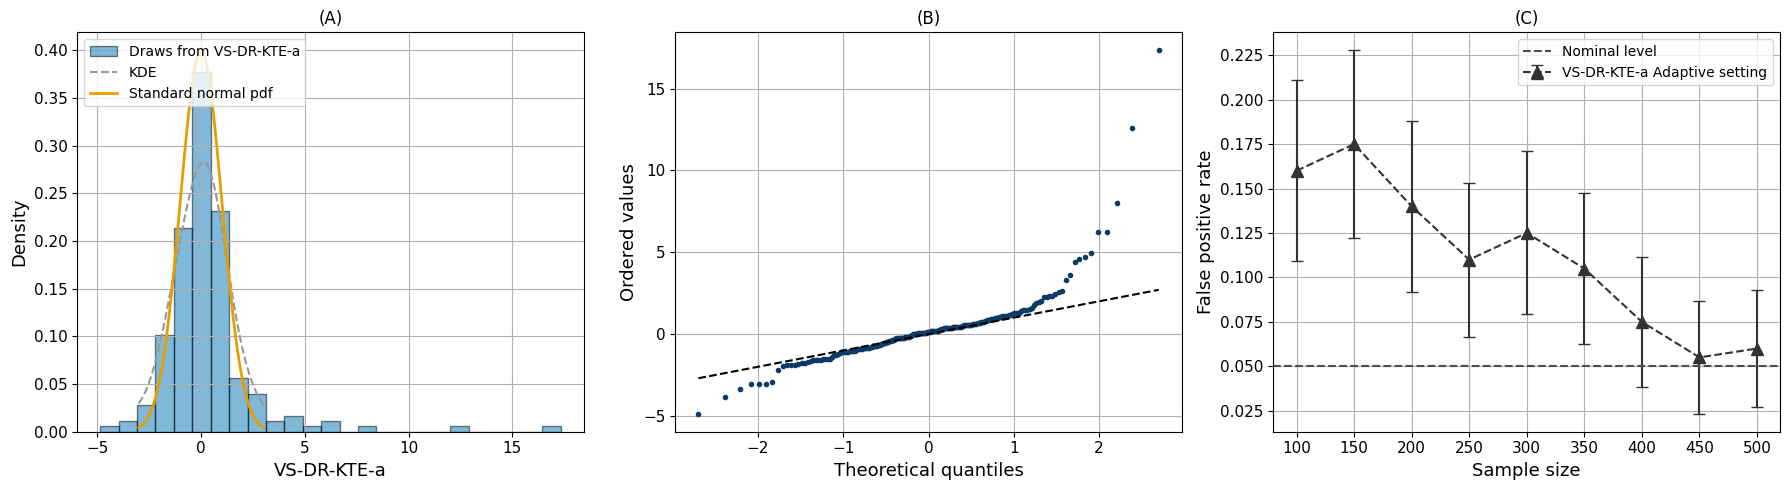

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot, gaussian_kde

# --- Styling (mimics your "sns-like" setup) ---
plt.rcParams["figure.figsize"] = (18, 5)
plt.rcParams["axes.grid"] = True
plt.rc("axes", labelsize=13)
plt.rc("xtick", labelsize=11)
plt.rc("ytick", labelsize=11)

# Colorblind-safe palette
cb_colors = {
    "hist": "#0072B2",     # blue
    "pdf": "#E69F00",      # orange
    "kde": "#999999",      # grey
    "qq": "#0D3B66",       # navy
    "nominal": "#4D4D4D"   # dark grey
}
# Per-method colors for panel (C)
method_colors = {
    "VS-DR-KTE": "#56B4E9",  # light blue
    "DR-xKTE":   "#009E73",  # green
    "IPW-xKTE":  "#CC79A7",  # pink
    "KTE":       "#F0E442"   # yellow (unused but available)
}
m_dict = {0: "^", 1: "s", 2: "v", 3: "o", 4: "D"}
m_dict_title = {0: " Adaptive setting", 1: " Observational setting", 2:"Adaptive Setting"}
method_dict = {'VS-DR-KTE_alternating': 'VS-DR-KTE-a', 'VS-DR-KTE_chronological': 'VS-DR-KTE-c', 'DR-xKTE': 'AIPW-xKTE', 'IPW-xKTE': 'IPW-xKTE', 'KTE': 'KTE'}

# --- Inputs matching your original snippet ---
case = 1
b = 'I'
ns = 250
method = 'VS-DR-KTE_alternating'
# method = 'VS-DR-KTE_chronological'
experiment = 'adaptive_rebuttal'
name_folder = f"results/{experiment}/"
os.makedirs("plots", exist_ok=True)

# ===================== (A) HIST + KDE + NORMAL PDF =====================
plt.subplot(1, 3, 1)
fname = f"{name_folder}ns{ns}b{b}{method}.csv"
stat_values = d[fname]['stat_values']
x_axis = np.linspace(-3, 3, 500)

# Histogram
plt.hist(
    stat_values,
    bins=25,
    density=True,
    color=cb_colors["hist"],
    alpha=0.5,
    edgecolor="black",
    label=f"Draws from {method_dict[method]}"
)

# KDE
kde = gaussian_kde(stat_values)
plt.plot(x_axis, kde(x_axis), linestyle="--", color=cb_colors["kde"], label="KDE")

# Standard Normal PDF
plt.plot(x_axis, norm.pdf(x_axis), linewidth=2, color=cb_colors["pdf"], label="Standard normal pdf")

plt.xlabel(method_dict[method])
plt.ylabel("Density")
plt.title("(A)")
plt.legend(loc="upper left")

# ============================== (B) QQ-PLOT ==============================
plt.subplot(1, 3, 2)
osm, osr = probplot(stat_values, dist="norm")[0]
plt.plot(osm, osr, marker='o', linestyle='', color=cb_colors["qq"], markersize=3)
plt.plot(osm, osm, color="black", linestyle="--")
plt.title("(B)")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered values")

# ===== (C) FALSE POSITIVE RATE (multi-method) WITH ERROR BARS =====
plt.subplot(1, 3, 3)
confidence_level = 0.05
method_list = ['VS-DR-KTE_alternating']
# method_list = ['VS-DR-KTE_chronological']

name_folder_list = [f"results/{experiment}/"]
ns_array = np.array(ns_list)

for k, nf in enumerate(name_folder_list):
    for i, mth in enumerate(method_list):
        rejection_proportion = np.zeros(len(ns_list))
        n_per_file = None

        for j, ns_val in enumerate(ns_list):
            f = f"{nf}ns{ns_val}b{b}{mth}.csv"
            pvals = d[f]['p_values']
            rejection_proportion[j] = (pvals < confidence_level).mean()
            n_per_file = len(pvals)  # assume constant across ns for varhat

        varhat = rejection_proportion * (1 - rejection_proportion) / n_per_file

        plt.errorbar(
            x=ns_array,
            y=rejection_proportion,
            yerr=1.96 * np.sqrt(varhat),
            capsize=4,
            marker=m_dict.get(k, "o"),
            markersize=8,
            color=method_colors.get(mth, "#333333"),
            linestyle='--',
            label=method_dict[mth] + m_dict_title[k]
        )

plt.axhline(confidence_level, color=cb_colors["nominal"], linestyle="--", label="Nominal level")
plt.title("(C)")
plt.xlabel("Sample size")
plt.ylabel("False positive rate")
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"plots/REVIEWED_null_dr_adaptive_sigmoidal{case}_errorbar.png", bbox_inches='tight')
plt.show()


## H1 scenarios II, III, IV

In [9]:
num_experiments=200
iterations=100

ns_list = np.arange(100, 550, 50)
b_list = ['II', 'III']
method_list = ['VS-DR-KTE', 'DR-xKTE', 'KTE']
# method_list = ['DR-xKTE']


experiment = 'adaptive_rebuttal'
name_folder = 'results/' +str(experiment) + '/'
run_tests_adaptive(b_list, method_list, ns_list, name_folder, num_experiments, iterations, split="alternating")

b = II


100%|██████████| 9/9 [02:08<00:00, 14.30s/it]


b = III


100%|██████████| 9/9 [04:59<00:00, 33.23s/it]


In [10]:
# Scenario I adaptive setting
name_folder_list_adaptive_null = ['results/' + 'adaptive_rebuttal' + '/']
ns_list_false_null = ns_list
ns_array_false_null = np.array(ns_list_false_null)
b_list_false_null = ['II', 'III']
methods_false_null = ['VS-DR-KTE', 'DR-xKTE', 'KTE']
case_list_false_null = [1]

d = dict()

for name_folder in name_folder_list_adaptive_null:
    for b in b_list_false_null:
        for method in methods_false_null:
            for case in case_list_false_null:
                for ns in ns_array_false_null:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + method + '_alternating.csv'
                    d[name] = pd.read_csv(name, index_col = 0)

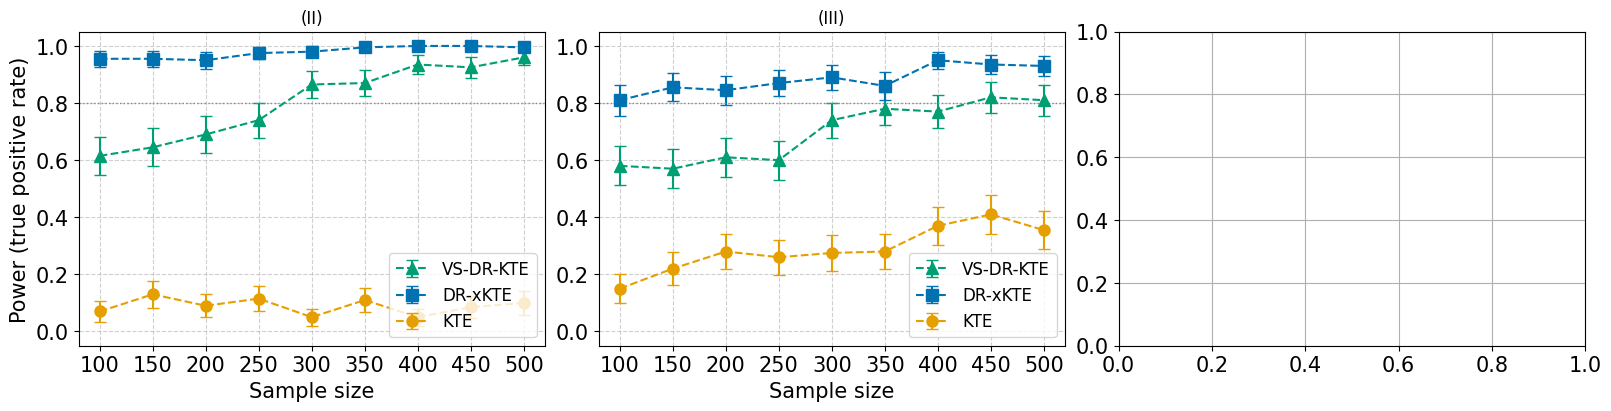

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_power_scenarios_adaptive_alternative(
    d,
    scenario_list=["II", "III"],
    ns_list=[100, 150, 200, 250, 300, 350, 400],
    methods=['VS-DR-KTE', 'CADR', 'Hadad'],
    name_folder="results/adaptive_linear/",
    split_suffix="_alternating.csv",
    alpha=0.05,
    save_path="plots/adaptive_alternative_power.png"
):
    # === Styling ===
    plt.rcParams["figure.figsize"] = (16, 4)
    plt.rc("legend", fontsize=12)
    plt.rc("axes", labelsize=15)
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)
    plt.rcParams["axes.grid"] = True

    fig, axs = plt.subplots(1, 3, constrained_layout=True)

    # === Mappings ===
    method_label = {
        "VS-DR-KTE": "VS-DR-KTE",
        "DR-xKTE": "DR-xKTE",
        "KTE": "KTE",
    }
    colors = {
        "VS-DR-KTE": "#009E73",
        "DR-xKTE": "#0072B2",
        "KTE": "#E69F00",
    }
    markers = {0: "^", 1: "s", 2: "o", 3: "v", 4: "D"}
    scenario_titles = {"II": "(II)", "III": "(III)", "IV": "(IV)"}
    ns_array = np.array(ns_list)

    for col, scenario in enumerate(scenario_list):
        ax = axs[col]
        ax.set_title(scenario_titles.get(scenario, scenario))
        ax.set_ylim((-0.05, 1.05))
        ax.set_xlabel("Sample size")
        ax.set_xticks(ns_list)
        ax.grid(True, linestyle="--", alpha=0.6)
        if col == 0:
            ax.set_ylabel("Power (true positive rate)")

        for i, method in enumerate(methods):
            power_values = []
            n_per_point = []
            for ns in ns_list:
                fname = f"{name_folder}ns{ns}b{scenario}{method}{split_suffix}"
                pvals = d[fname]["p_values"]
                rej = (pvals < alpha).mean()
                power_values.append(rej)
                n_per_point.append(len(pvals))

            power_values = np.array(power_values)
            n_per_point = np.array(n_per_point)
            # Binomial SE for proportion, Wald 95% band (you can swap for Wilson if you prefer)
            varhat = power_values * (1 - power_values) / np.maximum(n_per_point, 1)
            yerr = 1.96 * np.sqrt(varhat)

            ax.errorbar(
                x=ns_array,
                y=power_values,
                yerr=yerr,
                capsize=4,
                marker=markers[i % len(markers)],
                linestyle='--',
                linewidth=1.5,
                markersize=8,
                label=method_label.get(method, method),
                color=colors.get(method, "#333333")
            )

        # Reference lines: nominal alpha (for orientation) and 80% power target
        # ax.axhline(alpha, color="black", linestyle=":", linewidth=1, label="α")
        ax.axhline(0.8, color="#888888", linestyle=":", linewidth=1)

        ax.legend(loc="lower right")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_power_scenarios_adaptive_alternative(
    d=d,
    scenario_list=['II','III'],
    ns_list=ns_list,
    methods=['VS-DR-KTE', 'DR-xKTE', 'KTE'],
    name_folder='results/adaptive_rebuttal/',
    split_suffix='_alternating.csv',
    alpha=0.05,
    save_path='plots/scenarios_II_III_IV_adaptive_power.png'
)

In [12]:
import os
import numpy as np
import pandas as pd

def aggregate_results_adaptive(
    name_folder="results/adaptive_rebuttal/",
    scenario_list=("I", "II", "III"),
    ns_list_null=np.arange(100, 550, 50),   # from cell 7
    ns_list_alt=np.arange(100, 550, 50),    # from cell 12
    methods=("VS-DR-KTE", "DR-xKTE", "KTE"),
    split_suffix="_alternating.csv",
    alpha=0.05,
):
    rows = []

    # Scenario I (null) uses ns_list_null; II–IV use ns_list_alt
    for scenario in scenario_list:
        if scenario == "I":
            ns_list = ns_list_null
        else:
            ns_list = ns_list_alt

        for method in methods:
            for ns in ns_list:
                fname = f"{name_folder}ns{ns}b{scenario}{method}{split_suffix}"
                if not os.path.exists(fname):
                    # skip missing files
                    continue

                df = pd.read_csv(fname)
                pvals = df["p_values"].values
                stat_vals = df["stat_values"].values
                times = df["times"].values

                rej = (pvals < alpha).mean()
                rows.append(
                    {
                        "scenario": scenario,
                        "ns": ns,
                        "method": method,
                        "rej_rate": rej,
                        "mean_stat": stat_vals.mean(),
                        "mean_time": times.mean(),
                        "n_experiments": len(pvals),
                    }
                )

    results_df = pd.DataFrame(rows)
    return results_df

results_table = aggregate_results_adaptive()
results_table

results_pivot = (
    results_table
    .pivot_table(
        index=["scenario", "ns"],
        columns="method",
        values="rej_rate",
    )
    .reset_index()
)

results_pivot

method,scenario,ns,DR-xKTE,KTE,VS-DR-KTE
0,I,100,0.250,0.070,0.160
1,I,150,0.225,0.050,0.175
2,I,200,0.190,0.075,0.140
3,I,250,0.195,0.040,0.110
4,I,300,0.175,0.060,0.125
5,I,350,0.190,0.035,0.105
6,I,400,0.155,0.045,0.075
7,I,450,0.170,0.045,0.055
8,I,500,0.125,0.025,0.060
9,II,100,0.955,0.070,0.615


In [13]:
# --- Build the master results table ---
results_table = aggregate_results_adaptive()

# --- Produce one transposed table per scenario ---
scenario_tables = {}

for scenario in results_table["scenario"].unique():
    df_s = results_table[results_table["scenario"] == scenario]

    # Pivot: rows = methods, columns = ns
    table = (
        df_s.pivot_table(
            index="method",
            columns="ns",
            values="rej_rate",
        )
        .sort_index(axis=1)
        .sort_index(axis=0)
    )

    scenario_tables[scenario] = table

# Display all scenario-specific tables
for scenario, table in scenario_tables.items():
    print(f"\n===== Scenario {scenario} =====\n")
    display(table)



===== Scenario I =====



ns,100,150,200,250,300,350,400,450,500
method,,,,,,,,,
DR-xKTE,0.25,0.225,0.190,0.195,0.175,0.190,0.155,0.170,0.125
KTE,0.07,0.050,0.075,0.040,0.060,0.035,0.045,0.045,0.025
VS-DR-KTE,0.16,0.175,0.140,0.110,0.125,0.105,0.075,0.055,0.060



===== Scenario II =====



ns,100,150,200,250,300,350,400,450,500
method,,,,,,,,,
DR-xKTE,0.955,0.955,0.95,0.975,0.980,0.995,1.000,1.000,0.995
KTE,0.070,0.130,0.09,0.115,0.050,0.110,0.050,0.085,0.100
VS-DR-KTE,0.615,0.645,0.69,0.740,0.865,0.870,0.935,0.925,0.960



===== Scenario III =====



ns,100,150,200,250,300,350,400,450,500
method,,,,,,,,,
DR-xKTE,0.81,0.855,0.845,0.87,0.890,0.86,0.95,0.935,0.930
KTE,0.15,0.220,0.280,0.26,0.275,0.28,0.37,0.410,0.355
VS-DR-KTE,0.58,0.570,0.610,0.60,0.740,0.78,0.77,0.820,0.810
